# 02. 통계 모델링 & 위험지수 (point-biserial, OLS 상호작용, 표준화 위험점수)

원본 통합노트북 셀 41~63. PPT의 상관계수 유의미 범위, BMI×흡연 상호작용, 4개 집단 표준화 위험점수/파이차트 슬라이드와 대응됩니다. 자세한 매핑은 `docs/02_analysis_pipeline.md` 참고.

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = sorted(set(
    f.name for f in fm.fontManager.ttflist
    if 'Nanum' in f.name
))
print(nanum_fonts)

[]


In [ ]:
!ls /usr/share/fonts/truetype/nanum

NanumBarunGothicBold.ttf   NanumGothicCoding.ttf  NanumSquareB.ttf
NanumBarunGothic.ttf	   NanumGothic.ttf	  NanumSquareRoundB.ttf
NanumGothicBold.ttf	   NanumMyeongjoBold.ttf  NanumSquareRoundR.ttf
NanumGothicCodingBold.ttf  NanumMyeongjo.ttf	  NanumSquareR.ttf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print("사용 폰트:", font_name)

사용 폰트: NanumGothic


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

COLOR_SMOKER = '#A63A50'
COLOR_HIGH_BMI = '#C65D6E'
COLOR_NONSMOKER = '#6B7075'
COLOR_LOW_BMI = '#2F3437'
COLOR_TEXT = '#1E1E1E'
COLOR_GRID = '#D9D9D9'

plt.rcParams['axes.unicode_minus'] = False


train = pd.read_csv('/content/train_dataset.csv')


train_clean = train[
    (train['Gtp'] < 500) &
    (train['ALT'] < 500) &
    (train['AST'] < 500) &
    (train['LDL'] < 400) &
    (train['serum creatinine'] < 3.0) &
    (train['eyesight(left)'] <= 3.0) &
    (train['eyesight(right)'] <= 3.0)
].copy()

# BMI 생성
train_clean['BMI'] = train_clean['weight(kg)'] / ((train_clean['height(cm)'] / 100) ** 2)

# 고BMI 변수 생성
train_clean['high_BMI'] = (train_clean['BMI'] >= 25).astype(int)

# 연령대 변수 생성
train_clean['age_group'] = pd.cut(
    train_clean['age'],
    bins=[15, 29, 39, 49, 59, 69, 120],
    labels=['20대', '30대', '40대', '50대', '60대', '70대+']
)

print("원본 데이터 크기:", train.shape)
print("전처리 후 데이터 크기:", train_clean.shape)
display(train_clean.head())
display(train_clean.describe())

원본 데이터 크기: (38984, 23)
전처리 후 데이터 크기: (38740, 26)


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,high_BMI,age_group
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,1,1.0,61,115,125,1,1,29.411765,1,30대
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,1,1.1,19,25,30,1,0,35.918367,1,20대
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,1,0.9,32,36,36,0,0,29.384757,1,40대
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,1,1.2,26,28,15,0,0,22.038567,0,20대
5,60,160,50,78.0,1.0,0.9,2,2,126,75,...,1,1.0,47,23,70,0,1,19.531250,0,60대


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,high_BMI
count,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,...,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000
mean,44.077568,164.695534,65.941533,82.047630,0.999411,0.993645,1.025013,1.025761,121.442204,75.980305,...,14.623696,1.085003,0.884228,25.877956,26.692669,38.710712,0.214584,0.366882,24.179562,0.357073
std,12.041763,9.191880,12.895172,9.325185,0.326393,0.325241,0.156166,0.158425,13.632417,9.658122,...,1.566662,0.396592,0.191950,13.597727,20.422636,41.335390,0.410539,0.481960,3.502443,0.479143
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.900000,1.000000,0.100000,6.000000,1.000000,3.000000,0.000000,0.000000,14.268728,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000,21.604938,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000,23.875115,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000,26.122449,1.000000
max,85.000000,190.000000,135.000000,129.000000,2.000000,2.000000,2.000000,2.000000,233.000000,146.000000,...,21.100000,6.000000,2.600000,387.000000,471.000000,497.000000,1.000000,1.000000,42.448980,1.000000


In [ ]:
#흡연과상관관계분석
cont_cols = [
    'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
    'eyesight(left)', 'eyesight(right)',
    'systolic', 'relaxation', 'fasting blood sugar',
    'Cholesterol', 'triglyceride', 'HDL', 'LDL',
    'hemoglobin', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'BMI'
]

corr_rows = []
for col in cont_cols:
    r, p = stats.pointbiserialr(train_clean['smoking'], train_clean[col])
    corr_rows.append([col, r, p])

corr_df = pd.DataFrame(corr_rows, columns=['variable', 'correlation', 'p_value'])
corr_df = corr_df.sort_values('correlation', ascending=True)

display(corr_df)

,variable,correlation,p_value
11,HDL,-0.180899,2.966365e-282
0,age,-0.167949,5.021581e-243
12,LDL,-0.053937,2.318489e-26
9,Cholesterol,-0.027135,9.209622e-08
6,systolic,0.070547,6.143091e-44
15,AST,0.082912,4.584430e-60
4,eyesight(left),0.097287,4.196468e-82
8,fasting blood sugar,0.098298,8.702630e-84
7,relaxation,0.104368,2.875241e-94
5,eyesight(right),0.105975,3.775822e-97


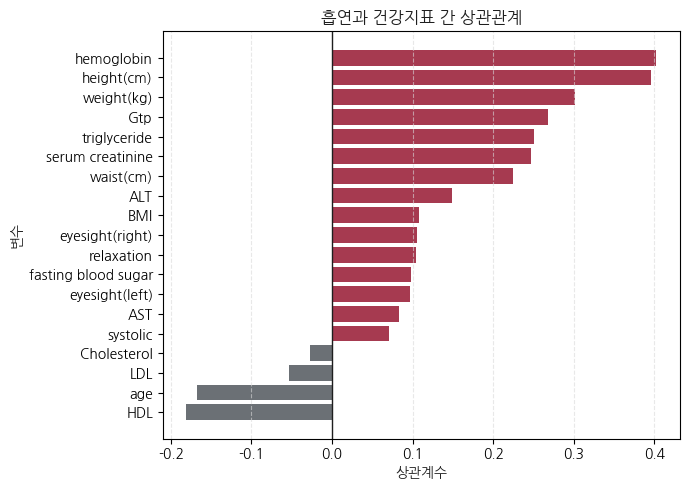

In [ ]:
#상관관계시각화
bar_colors = [COLOR_SMOKER if x > 0 else COLOR_NONSMOKER for x in corr_df['correlation']]

plt.figure(figsize=(7, 5))
plt.barh(corr_df['variable'], corr_df['correlation'], color=bar_colors)
plt.axvline(0, color=COLOR_TEXT, linewidth=1)

plt.title('흡연과 건강지표 간 상관관계', color=COLOR_TEXT)
plt.xlabel('상관계수', color=COLOR_TEXT)
plt.ylabel('변수', color=COLOR_TEXT)
plt.grid(axis='x', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

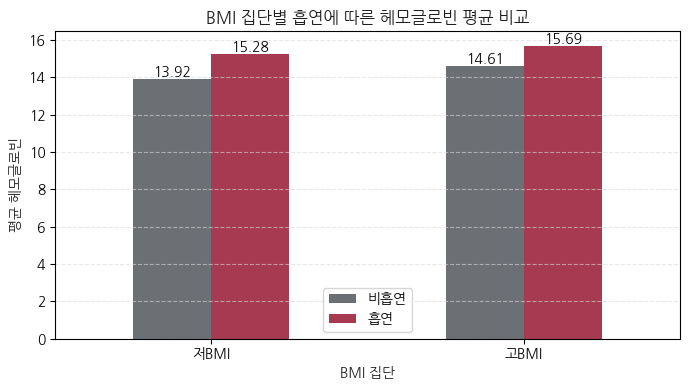

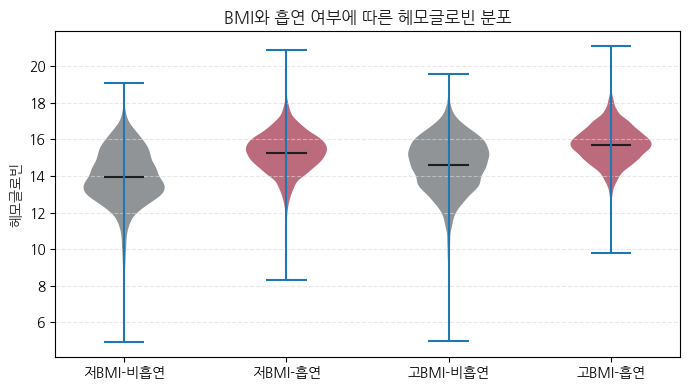

                            OLS Regression Results                            
Dep. Variable:             hemoglobin   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     3636.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:49:41   Log-Likelihood:                -68167.
No. Observations:               38740   AIC:                         1.363e+05
Df Residuals:                   38736   BIC:                         1.364e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           13.9234      0.012  

In [ ]:
#가설1_흡연은 혈관 관련 건강지표를 악화시킬 것이다
#세부가설1-1_어느 BMI 집단에 속해있어도 흡연은 헤모글로빈 수치를 증가시킬 것이다

#BMI 집단별 헤모글로빈 평균 막대그래프
hemo_plot = train_clean.groupby(['high_BMI', 'smoking'])['hemoglobin'].mean().unstack()
hemo_plot.index = ['저BMI', '고BMI']
hemo_plot.columns = ['비흡연', '흡연']

ax = hemo_plot.plot(
    kind='bar',
    figsize=(7,4),
    color=[COLOR_NONSMOKER, COLOR_SMOKER]
)

plt.title('BMI 집단별 흡연에 따른 헤모글로빈 평균 비교', color=COLOR_TEXT)
plt.xlabel('BMI 집단', color=COLOR_TEXT)
plt.ylabel('평균 헤모글로빈', color=COLOR_TEXT)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#BMI 집단별 헤모글로빈 바이올린플롯
groups = [
    train_clean[(train_clean['high_BMI']==0) & (train_clean['smoking']==0)]['hemoglobin'],
    train_clean[(train_clean['high_BMI']==0) & (train_clean['smoking']==1)]['hemoglobin'],
    train_clean[(train_clean['high_BMI']==1) & (train_clean['smoking']==0)]['hemoglobin'],
    train_clean[(train_clean['high_BMI']==1) & (train_clean['smoking']==1)]['hemoglobin']
]

fig, ax = plt.subplots(figsize=(7,4))
parts = ax.violinplot(groups, showmeans=True, showmedians=False)


for i, body in enumerate(parts['bodies']):
    if i in [0, 2]:
        body.set_facecolor(COLOR_NONSMOKER)
    else:
        body.set_facecolor(COLOR_SMOKER)
    body.set_alpha(0.75)

parts['cmeans'].set_color(COLOR_TEXT)

ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['저BMI-비흡연', '저BMI-흡연', '고BMI-비흡연', '고BMI-흡연'])
ax.set_title('BMI와 흡연 여부에 따른 헤모글로빈 분포', color=COLOR_TEXT)
ax.set_ylabel('헤모글로빈', color=COLOR_TEXT)
ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

model_hemo = smf.ols('hemoglobin ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
print(model_hemo.summary())


(38740, 23)


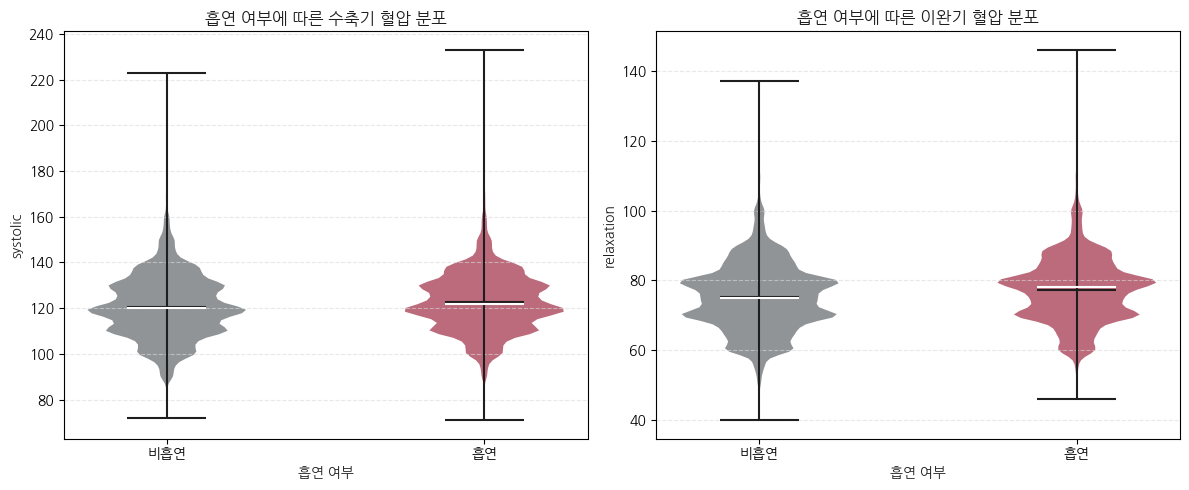

비흡연자 systolic 평균: 120.71011538304725
흡연자 systolic 평균: 122.70555125589249
비흡연자 relaxation 평균: 75.2129897663799
흡연자 relaxation 평균: 77.30443959755154
원본 데이터 크기: (38984, 23)
전처리 후 데이터 크기: (38740, 27)
              systolic             relaxation           
smoking              0           1          0          1
age_decade                                              
30대         121.757555  122.113443  76.244822  76.998689
40대         117.340656  122.543113  73.976527  78.164580
50대         121.064302  123.373872  75.951018  78.071766


/tmp/ipykernel_7478/1606899094.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp_mean = train_clean.groupby(['age_decade', 'smoking'])[['systolic', 'relaxation']].mean().unstack()
/tmp/ipykernel_7478/1606899094.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sys_pivot = train_clean.groupby(['age_decade', 'smoking'])['systolic'].mean().unstack()
/tmp/ipykernel_7478/1606899094.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

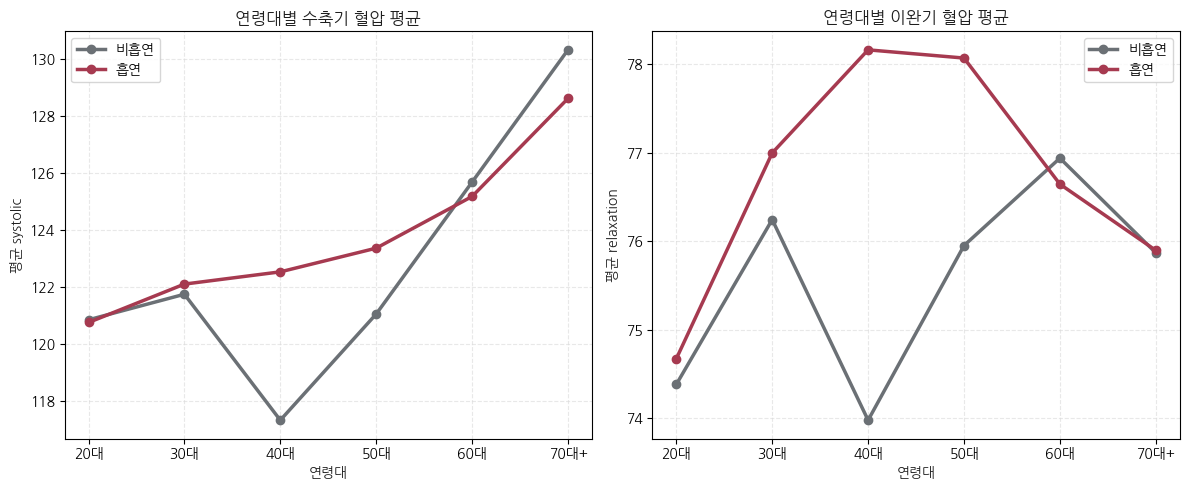

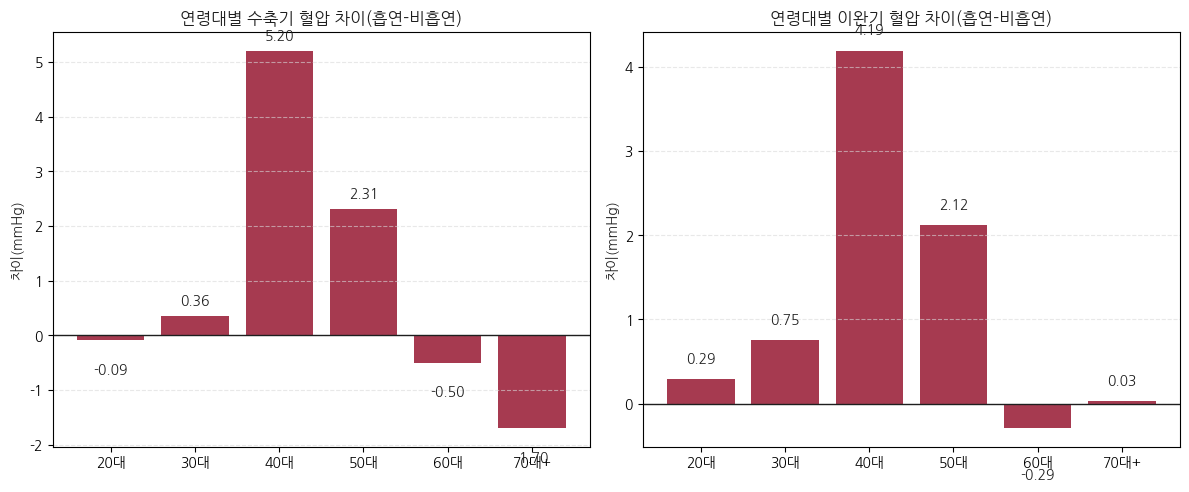

/tmp/ipykernel_7478/1606899094.py:205: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  htn_prev = train_clean.groupby(['age_decade', 'smoking'])['htn'].mean().unstack()


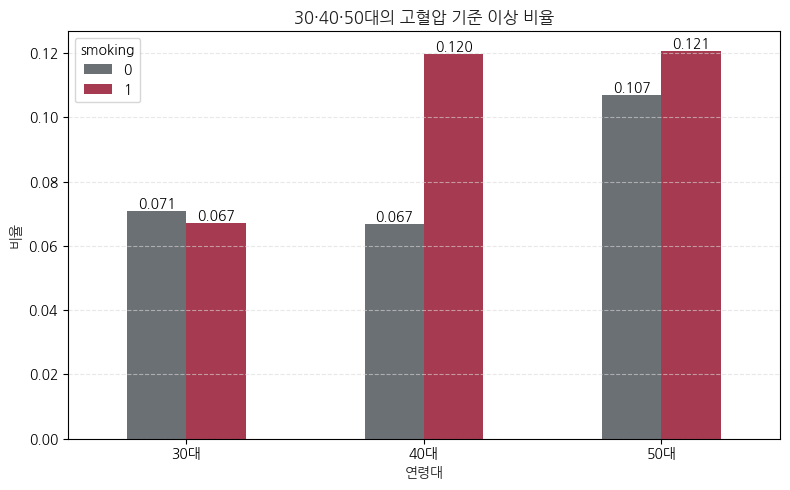

/tmp/ipykernel_7478/1606899094.py:251: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoke_prev = train_clean.groupby('age_decade')['smoking'].mean()
/tmp/ipykernel_7478/1606899094.py:252: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoke_count = train_clean.groupby('age_decade')['smoking'].agg(['sum', 'count'])


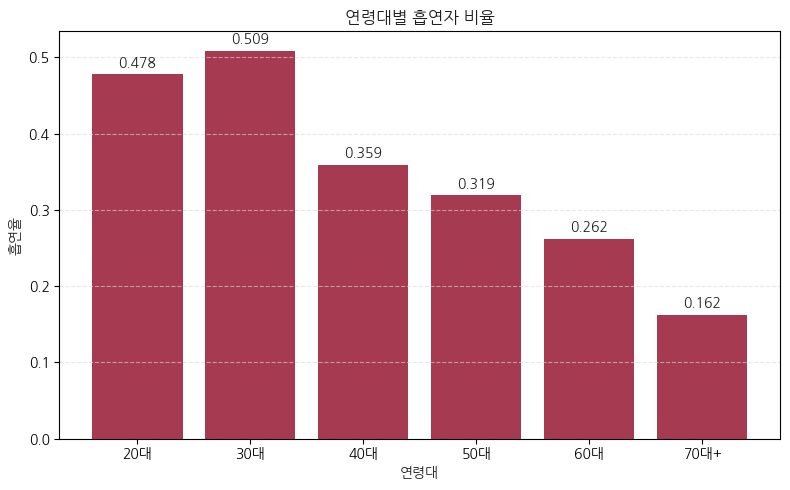

                            OLS Regression Results                            
Dep. Variable:               systolic   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     1045.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:51:41   Log-Likelihood:            -1.5354e+05
No. Observations:               38740   AIC:                         3.071e+05
Df Residuals:                   38734   BIC:                         3.071e+05
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            87.3473      0.57

/tmp/ipykernel_7478/1606899094.py:288: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bp = train_clean.groupby('age_decade')[['systolic', 'relaxation']].mean()


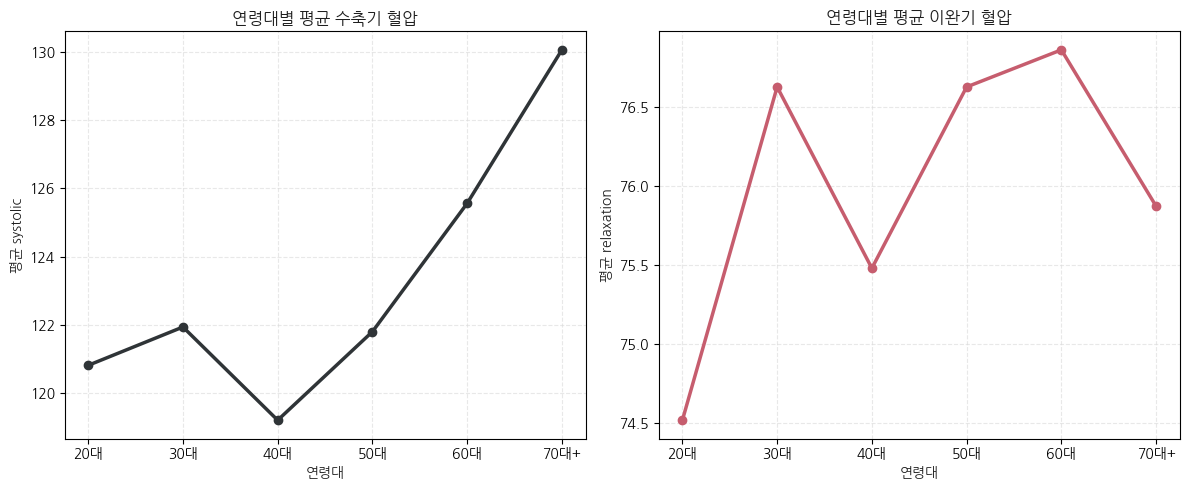

/tmp/ipykernel_7478/1606899094.py:310: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp_60plus_mean = bp_60plus.groupby(['age_decade', 'smoking'])[['systolic', 'relaxation']].mean().unstack()


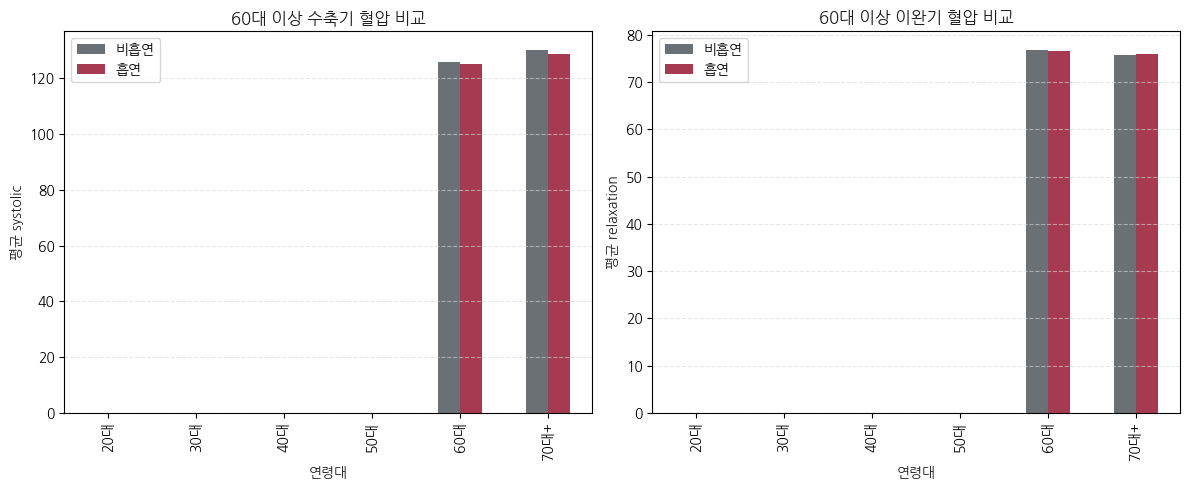

나이-수축기 혈압 상관: 0.13146546099696194 6.823451617092005e-149
나이-이완기 혈압 상관: 0.048628818931809814 1.0018153302605143e-21


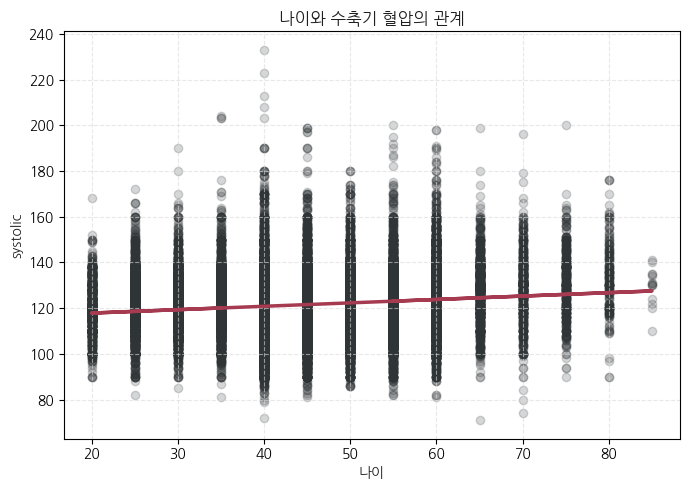

/tmp/ipykernel_7478/1606899094.py:357: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_htn = train_clean.groupby('age_decade')['htn'].mean()


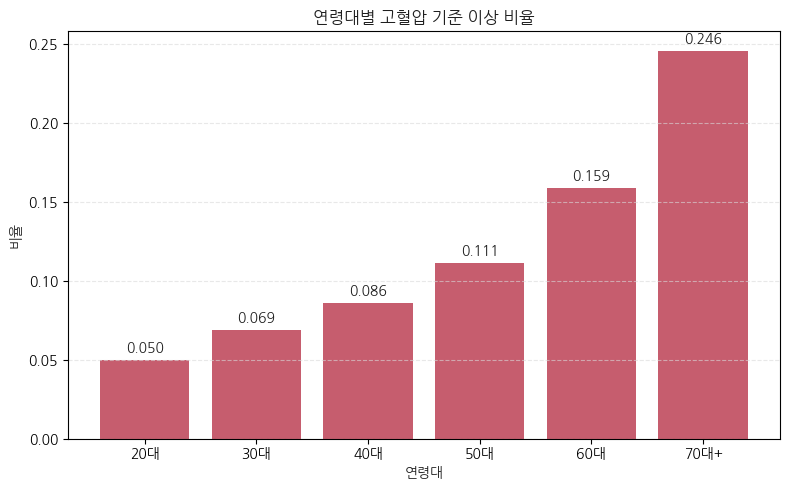

In [ ]:
#가설1_흡연은 혈관 관련 건강지표를 악화시킬 것이다
#세부가설1-2_흡연자는 비흡연자보다 혈압이 더 높게 나타날 것이다
#연령대별로 나누어 특정 연령대에서 결과가 두드러지는지 비교

#전체혈압_바이올린플롯
import pandas as pd

train = pd.read_csv('/content/train_dataset.csv')

train_clean = train[
    (train['Gtp'] < 500) &
    (train['ALT'] < 500) &
    (train['AST'] < 500) &
    (train['LDL'] < 400) &
    (train['serum creatinine'] < 3.0) &
    (train['eyesight(left)'] <= 3.0) &
    (train['eyesight(right)'] <= 3.0)
].copy()

print(train_clean.shape)
train_clean.head()

import matplotlib.pyplot as plt

# 색상
COLOR_SMOKER = '#A63A50'
COLOR_NONSMOKER = '#6B7075'
COLOR_TEXT = '#1E1E1E'
COLOR_GRID = '#D9D9D9'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


#수축기 혈압(systolic)
sys_data = [
    train_clean[train_clean['smoking'] == 0]['systolic'].dropna(),
    train_clean[train_clean['smoking'] == 1]['systolic'].dropna()
]

parts1 = axes[0].violinplot(sys_data, showmeans=True, showmedians=True)

for i, body in enumerate(parts1['bodies']):
    body.set_facecolor(COLOR_NONSMOKER if i == 0 else COLOR_SMOKER)
    body.set_alpha(0.75)

parts1['cmeans'].set_color(COLOR_TEXT)
parts1['cmedians'].set_color('white')
parts1['cbars'].set_color(COLOR_TEXT)
parts1['cmins'].set_color(COLOR_TEXT)
parts1['cmaxes'].set_color(COLOR_TEXT)

axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['비흡연', '흡연'])
axes[0].set_title('흡연 여부에 따른 수축기 혈압 분포', color=COLOR_TEXT)
axes[0].set_xlabel('흡연 여부', color=COLOR_TEXT)
axes[0].set_ylabel('systolic', color=COLOR_TEXT)
axes[0].grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)


#이완기 혈압(relaxation)

dia_data = [
    train_clean[train_clean['smoking'] == 0]['relaxation'].dropna(),
    train_clean[train_clean['smoking'] == 1]['relaxation'].dropna()
]

parts2 = axes[1].violinplot(dia_data, showmeans=True, showmedians=True)

for i, body in enumerate(parts2['bodies']):
    body.set_facecolor(COLOR_NONSMOKER if i == 0 else COLOR_SMOKER)
    body.set_alpha(0.75)

parts2['cmeans'].set_color(COLOR_TEXT)
parts2['cmedians'].set_color('white')
parts2['cbars'].set_color(COLOR_TEXT)
parts2['cmins'].set_color(COLOR_TEXT)
parts2['cmaxes'].set_color(COLOR_TEXT)

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['비흡연', '흡연'])
axes[1].set_title('흡연 여부에 따른 이완기 혈압 분포', color=COLOR_TEXT)
axes[1].set_xlabel('흡연 여부', color=COLOR_TEXT)
axes[1].set_ylabel('relaxation', color=COLOR_TEXT)
axes[1].grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

print("비흡연자 systolic 평균:", train_clean[train_clean['smoking'] == 0]['systolic'].mean())
print("흡연자 systolic 평균:", train_clean[train_clean['smoking'] == 1]['systolic'].mean())

print("비흡연자 relaxation 평균:", train_clean[train_clean['smoking'] == 0]['relaxation'].mean())
print("흡연자 relaxation 평균:", train_clean[train_clean['smoking'] == 1]['relaxation'].mean())

#연령대별 평균혈압
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

COLOR_SMOKER = '#A63A50'
COLOR_HIGH_BMI = '#C65D6E'
COLOR_NONSMOKER = '#6B7075'
COLOR_LOW_BMI = '#2F3437'
COLOR_TEXT = '#1E1E1E'
COLOR_GRID = '#D9D9D9'

plt.rcParams['axes.unicode_minus'] = False
train = pd.read_csv('/content/train_dataset.csv')
train_clean = train[
    (train['Gtp'] < 500) &
    (train['ALT'] < 500) &
    (train['AST'] < 500) &
    (train['LDL'] < 400) &
    (train['serum creatinine'] < 3.0) &
    (train['eyesight(left)'] <= 3.0) &
    (train['eyesight(right)'] <= 3.0)
].copy()

train_clean['BMI'] = train_clean['weight(kg)'] / ((train_clean['height(cm)'] / 100) ** 2)
train_clean['high_BMI'] = (train_clean['BMI'] >= 25).astype(int)

train_clean['age_decade'] = pd.cut(
    train_clean['age'],
    bins=[19, 29, 39, 49, 59, 69, 120],
    labels=['20대', '30대', '40대', '50대', '60대', '70대+']
)

# 고혈압 위험 변수 생성
# WHO는 성인의 임상적 고혈압_140/90 mmHg 이상
train_clean['htn'] = (
    (train_clean['systolic'] >= 140) | (train_clean['relaxation'] >= 90)
).astype(int)

print("원본 데이터 크기:", train.shape)
print("전처리 후 데이터 크기:", train_clean.shape)
train_clean.head()
bp_mean = train_clean.groupby(['age_decade', 'smoking'])[['systolic', 'relaxation']].mean().unstack()

#30-50대만 확인
bp_mean_3050 = bp_mean.loc[['30대', '40대', '50대']]
print(bp_mean_3050)
#선그래프_시각화
sys_pivot = train_clean.groupby(['age_decade', 'smoking'])['systolic'].mean().unstack()
dia_pivot = train_clean.groupby(['age_decade', 'smoking'])['relaxation'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sys_pivot.plot(
    marker='o',
    linewidth=2.5,
    ax=axes[0],
    color=[COLOR_NONSMOKER, COLOR_SMOKER]
)
axes[0].set_title('연령대별 수축기 혈압 평균', color=COLOR_TEXT)
axes[0].set_xlabel('연령대', color=COLOR_TEXT)
axes[0].set_ylabel('평균 systolic', color=COLOR_TEXT)
axes[0].grid(True, linestyle='--', color=COLOR_GRID, alpha=0.6)
axes[0].legend(['비흡연', '흡연'])

dia_pivot.plot(
    marker='o',
    linewidth=2.5,
    ax=axes[1],
    color=[COLOR_NONSMOKER, COLOR_SMOKER]
)
axes[1].set_title('연령대별 이완기 혈압 평균', color=COLOR_TEXT)
axes[1].set_xlabel('연령대', color=COLOR_TEXT)
axes[1].set_ylabel('평균 relaxation', color=COLOR_TEXT)
axes[1].grid(True, linestyle='--', color=COLOR_GRID, alpha=0.6)
axes[1].legend(['비흡연', '흡연'])

plt.tight_layout()
plt.show()

#막대그래프
sys_diff = sys_pivot[1] - sys_pivot[0]
dia_diff = dia_pivot[1] - dia_pivot[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(sys_diff.index.astype(str), sys_diff.values, color=COLOR_SMOKER)
axes[0].axhline(0, color=COLOR_TEXT, linewidth=1)
axes[0].set_title('연령대별 수축기 혈압 차이(흡연-비흡연)', color=COLOR_TEXT)
axes[0].set_ylabel('차이(mmHg)', color=COLOR_TEXT)
axes[0].grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(sys_diff.values):
    axes[0].text(i, v + (0.2 if v >= 0 else -0.6), f'{v:.2f}', ha='center', color=COLOR_TEXT)

axes[1].bar(dia_diff.index.astype(str), dia_diff.values, color=COLOR_SMOKER)
axes[1].axhline(0, color=COLOR_TEXT, linewidth=1)
axes[1].set_title('연령대별 이완기 혈압 차이(흡연-비흡연)', color=COLOR_TEXT)
axes[1].set_ylabel('차이(mmHg)', color=COLOR_TEXT)
axes[1].grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(dia_diff.values):
    axes[1].text(i, v + (0.2 if v >= 0 else -0.6), f'{v:.2f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

#연령대별_고혈압비교
htn_prev = train_clean.groupby(['age_decade', 'smoking'])['htn'].mean().unstack()
htn_prev_3050 = htn_prev.loc[['30대', '40대', '50대']]

ax = htn_prev_3050.plot(
    kind='bar',
    figsize=(8, 5),
    color=[COLOR_NONSMOKER, COLOR_SMOKER]
)

plt.title('30·40·50대의 고혈압 기준 이상 비율', color=COLOR_TEXT)
plt.xlabel('연령대', color=COLOR_TEXT)
plt.ylabel('비율', color=COLOR_TEXT)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

#연령대별_통계검정
rows = []
for grp in ['30대', '40대', '50대']:
    sub = train_clean[train_clean['age_decade'] == grp]
    s0 = sub[sub['smoking'] == 0]
    s1 = sub[sub['smoking'] == 1]

    p_sys = mannwhitneyu(s0['systolic'], s1['systolic'], alternative='two-sided').pvalue
    p_dia = mannwhitneyu(s0['relaxation'], s1['relaxation'], alternative='two-sided').pvalue

    rows.append([
        grp,
        s0['systolic'].mean(), s1['systolic'].mean(), s1['systolic'].mean() - s0['systolic'].mean(), p_sys,
        s0['relaxation'].mean(), s1['relaxation'].mean(), s1['relaxation'].mean() - s0['relaxation'].mean(), p_dia
    ])

bp_test = pd.DataFrame(rows, columns=[
    '연령대',
    '수축기_비흡연', '수축기_흡연', '수축기_차이', '수축기_p',
    '이완기_비흡연', '이완기_흡연', '이완기_차이', '이완기_p'
])

bp_test

#연령대별흡연율
smoke_prev = train_clean.groupby('age_decade')['smoking'].mean()
smoke_count = train_clean.groupby('age_decade')['smoking'].agg(['sum', 'count'])
smoke_prev_df = pd.concat([smoke_prev, smoke_count], axis=1)
smoke_prev_df.columns = ['흡연율', '흡연자수', '전체수']
smoke_prev_df
#연령대별 흡연율 막대그래프
plt.figure(figsize=(8, 5))
bars = plt.bar(smoke_prev.index.astype(str), smoke_prev.values, color=COLOR_SMOKER)

plt.title('연령대별 흡연자 비율', color=COLOR_TEXT)
plt.xlabel('연령대', color=COLOR_TEXT)
plt.ylabel('흡연율', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(smoke_prev.values):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

#60대 이상에서 연령과 BMI를 함께 통제한 회귀분석
train_clean['age60plus'] = (train_clean['age'] >= 60).astype(int)

model_sys = smf.ols(
    'systolic ~ smoking + age + BMI + age60plus + smoking:age60plus',
    data=train_clean
).fit(cov_type='HC3')

model_dia = smf.ols(
    'relaxation ~ smoking + age + BMI + age60plus + smoking:age60plus',
    data=train_clean
).fit(cov_type='HC3')

print(model_sys.summary())
print(model_dia.summary())

#60대 이상에서 비흡연자 혈압도 높아지는 모습 시각화
age_bp = train_clean.groupby('age_decade')[['systolic', 'relaxation']].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_bp['systolic'].plot(kind='line', marker='o', linewidth=2.5, color=COLOR_LOW_BMI, ax=axes[0])
axes[0].set_title('연령대별 평균 수축기 혈압', color=COLOR_TEXT)
axes[0].set_xlabel('연령대', color=COLOR_TEXT)
axes[0].set_ylabel('평균 systolic', color=COLOR_TEXT)
axes[0].grid(True, linestyle='--', color=COLOR_GRID, alpha=0.6)

age_bp['relaxation'].plot(kind='line', marker='o', linewidth=2.5, color=COLOR_HIGH_BMI, ax=axes[1])
axes[1].set_title('연령대별 평균 이완기 혈압', color=COLOR_TEXT)
axes[1].set_xlabel('연령대', color=COLOR_TEXT)
axes[1].set_ylabel('평균 relaxation', color=COLOR_TEXT)
axes[1].grid(True, linestyle='--', color=COLOR_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

#60대 이상 흡연/비흡연 비교 그래프
bp_60plus = train_clean[train_clean['age_decade'].isin(['60대', '70대+'])]

bp_60plus_mean = bp_60plus.groupby(['age_decade', 'smoking'])[['systolic', 'relaxation']].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bp_60plus_mean['systolic'].plot(kind='bar', ax=axes[0], color=[COLOR_NONSMOKER, COLOR_SMOKER])
axes[0].set_title('60대 이상 수축기 혈압 비교', color=COLOR_TEXT)
axes[0].set_ylabel('평균 systolic', color=COLOR_TEXT)
axes[0].set_xlabel('연령대', color=COLOR_TEXT)
axes[0].grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
axes[0].legend(['비흡연', '흡연'])

bp_60plus_mean['relaxation'].plot(kind='bar', ax=axes[1], color=[COLOR_NONSMOKER, COLOR_SMOKER])
axes[1].set_title('60대 이상 이완기 혈압 비교', color=COLOR_TEXT)
axes[1].set_ylabel('평균 relaxation', color=COLOR_TEXT)
axes[1].set_xlabel('연령대', color=COLOR_TEXT)
axes[1].grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
axes[1].legend(['비흡연', '흡연'])

plt.tight_layout()
plt.show()

#나이와혈압의상관관계
from scipy.stats import pearsonr

r_sys, p_sys = pearsonr(train_clean['age'], train_clean['systolic'])
r_dia, p_dia = pearsonr(train_clean['age'], train_clean['relaxation'])

print("나이-수축기 혈압 상관:", r_sys, p_sys)
print("나이-이완기 혈압 상관:", r_dia, p_dia)

#산점도_추세선
plt.figure(figsize=(7,5))
plt.scatter(train_clean['age'], train_clean['systolic'], alpha=0.2, color=COLOR_LOW_BMI, label='systolic')

# 추세선
z = np.polyfit(train_clean['age'], train_clean['systolic'], 1)
p = np.poly1d(z)
plt.plot(train_clean['age'], p(train_clean['age']), color=COLOR_SMOKER, linewidth=2.5)

plt.title('나이와 수축기 혈압의 관계', color=COLOR_TEXT)
plt.xlabel('나이', color=COLOR_TEXT)
plt.ylabel('systolic', color=COLOR_TEXT)
plt.grid(True, linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#연령대고혈압비율
age_htn = train_clean.groupby('age_decade')['htn'].mean()

plt.figure(figsize=(8,5))
bars = plt.bar(age_htn.index.astype(str), age_htn.values, color=COLOR_HIGH_BMI)

plt.title('연령대별 고혈압 기준 이상 비율', color=COLOR_TEXT)
plt.xlabel('연령대', color=COLOR_TEXT)
plt.ylabel('비율', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(age_htn.values):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

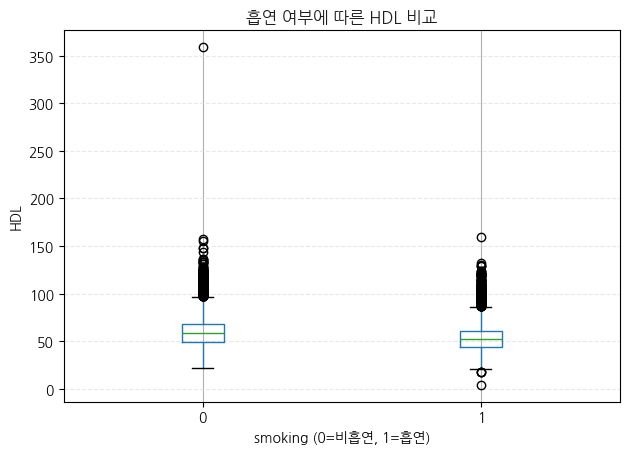

AttributeError: Rectangle.set() got an unexpected keyword argument 'figsize'

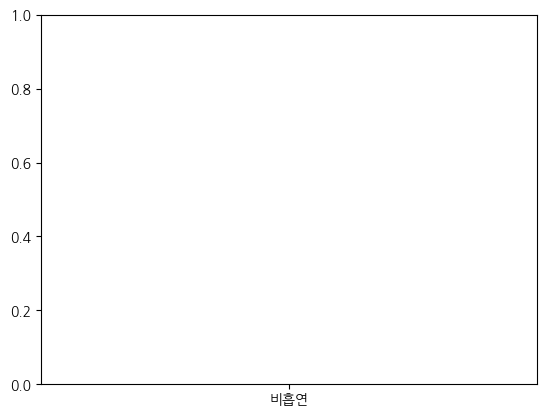

In [ ]:
#가설1
#세부가설1-3_HDL은 흡연자의 경우 안 좋은 데이터를 갖고 있을 것이다
plt.figure(figsize=(6,5))
train_clean.boxplot(column='HDL', by='smoking')

plt.title('흡연 여부에 따른 HDL 비교', color=COLOR_TEXT)
plt.suptitle('')
plt.xlabel('smoking (0=비흡연, 1=흡연)')
plt.ylabel('HDL')
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#평균비교막대


<Figure size 600x500 with 0 Axes>

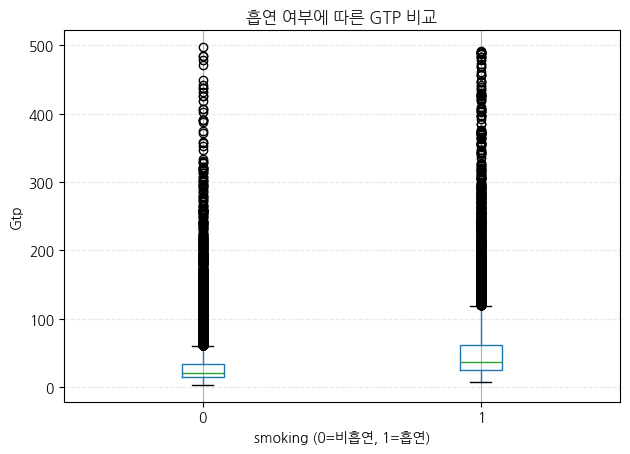

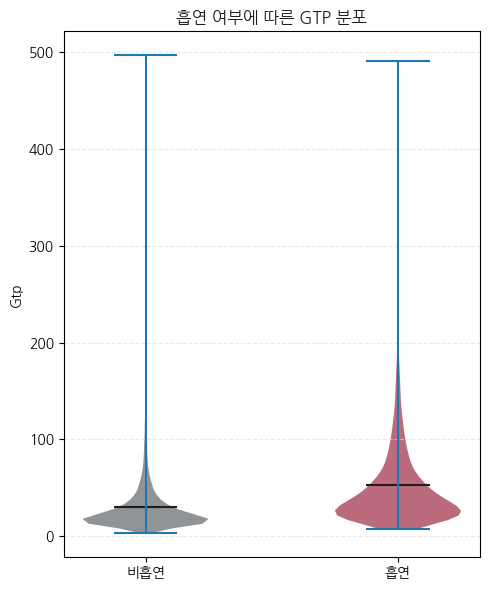

In [ ]:
#가설2_흡연은 간기능저하유발
#세부가설2-1_흡연자는 비흡연자보다 GTP가 더 높게 나타날 것이다
#gtp박스플롯
plt.figure(figsize=(6,5))
train_clean.boxplot(column='Gtp', by='smoking')

plt.title('흡연 여부에 따른 GTP 비교', color=COLOR_TEXT)
plt.suptitle('')
plt.xlabel('smoking (0=비흡연, 1=흡연)')
plt.ylabel('Gtp')
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#gtp바이올린플롯
groups = [
    train_clean[train_clean['smoking']==0]['Gtp'],
    train_clean[train_clean['smoking']==1]['Gtp']
]

fig, ax = plt.subplots(figsize=(5,6))
parts = ax.violinplot(groups, showmeans=True)

parts['bodies'][0].set_facecolor(COLOR_NONSMOKER)
parts['bodies'][1].set_facecolor(COLOR_SMOKER)
for b in parts['bodies']:
    b.set_alpha(0.75)
parts['cmeans'].set_color(COLOR_TEXT)

ax.set_xticks([1,2])
ax.set_xticklabels(['비흡연', '흡연'])
ax.set_ylabel('Gtp')
ax.set_title('흡연 여부에 따른 GTP 분포', color=COLOR_TEXT)
ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

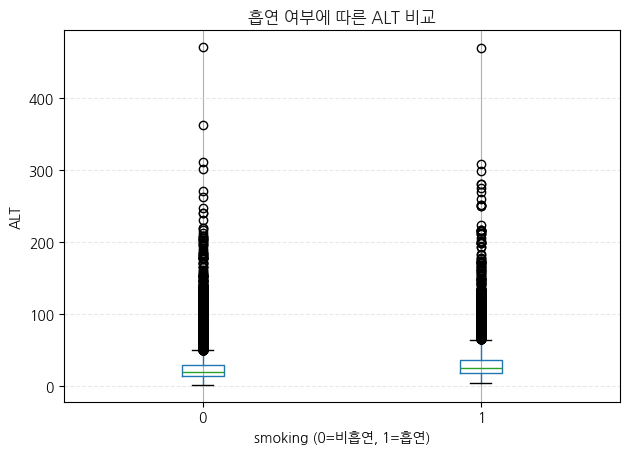

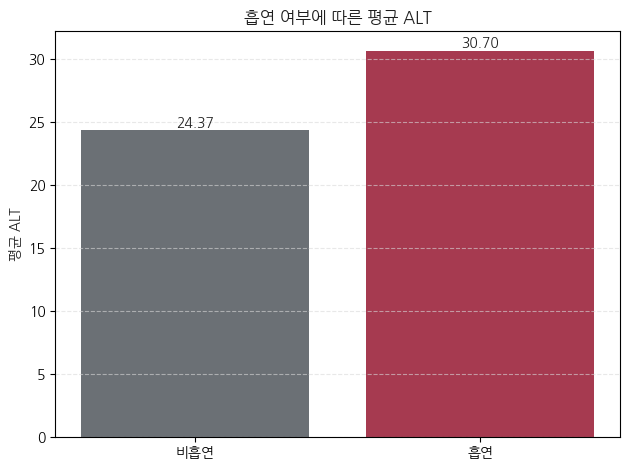

In [ ]:
#가설2_흡연은 간기능저하유발
#세부가설2-2_흡연은 ALT에 악영향을 미칠 것이다

#ALT 박스플롯
plt.figure(figsize=(6,5))
train_clean.boxplot(column='ALT', by='smoking')

plt.title('흡연 여부에 따른 ALT 비교', color=COLOR_TEXT)
plt.suptitle('')
plt.xlabel('smoking (0=비흡연, 1=흡연)')
plt.ylabel('ALT')
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#ALT 평균 막대그래프
alt_mean = train_clean.groupby('smoking')['ALT'].mean()
alt_mean.index = ['비흡연', '흡연']

bars = plt.bar(alt_mean.index, alt_mean.values, color=[COLOR_NONSMOKER, COLOR_SMOKER])
plt.title('흡연 여부에 따른 평균 ALT', color=COLOR_TEXT)
plt.ylabel('평균 ALT', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(alt_mean.values):
    plt.text(i, v+0.3, f'{v:.2f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

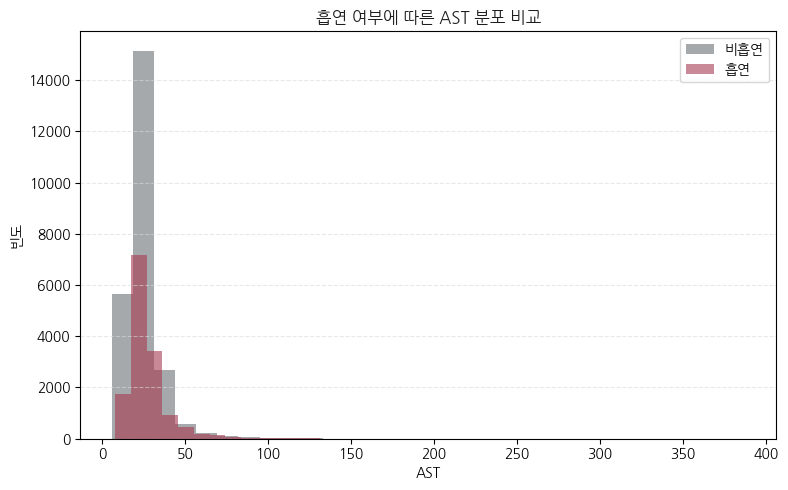

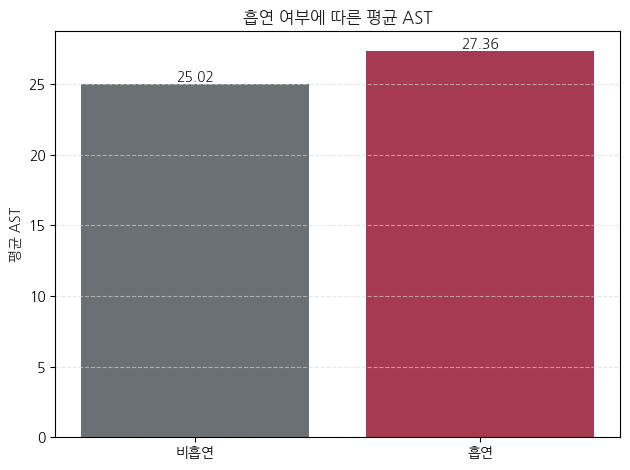

In [ ]:
#세부가설2-3_흡연은AST에악영향
#AST 히스토그램
plt.figure(figsize=(8,5))

plt.hist(train_clean[train_clean['smoking']==0]['AST'], bins=30, alpha=0.6,
         label='비흡연', color=COLOR_NONSMOKER)

plt.hist(train_clean[train_clean['smoking']==1]['AST'], bins=30, alpha=0.6,
         label='흡연', color=COLOR_SMOKER)

plt.title('흡연 여부에 따른 AST 분포 비교', color=COLOR_TEXT)
plt.xlabel('AST')
plt.ylabel('빈도')
plt.legend()
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()
#AST평균막대그래프
ast_mean = train_clean.groupby('smoking')['AST'].mean()
ast_mean.index = ['비흡연', '흡연']

bars = plt.bar(ast_mean.index, ast_mean.values, color=[COLOR_NONSMOKER, COLOR_SMOKER])
plt.title('흡연 여부에 따른 평균 AST', color=COLOR_TEXT)
plt.ylabel('평균 AST', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(ast_mean.values):
    plt.text(i, v+0.2, f'{v:.2f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()


=== GTP ===
                            OLS Regression Results                            
Dep. Variable:                    Gtp   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     1309.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:17:55   Log-Likelihood:            -1.9717e+05
No. Observations:               38740   AIC:                         3.943e+05
Df Residuals:                   38736   BIC:                         3.944e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           25.9569 

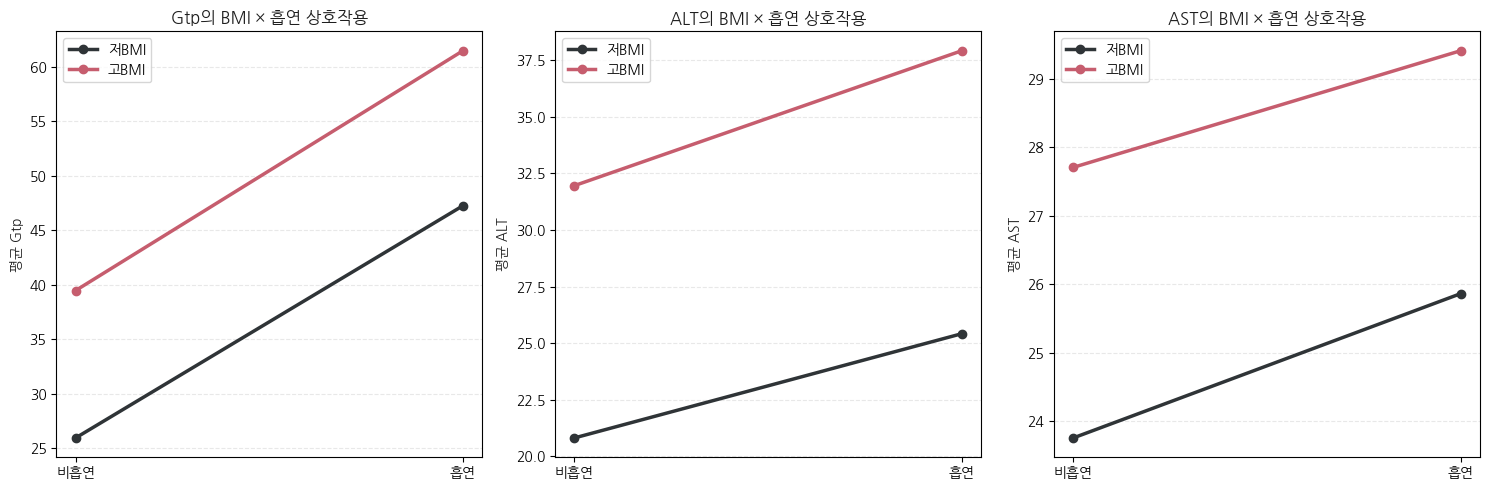

In [ ]:
#가설 3: 특히 고BMI 집단과 흡연이 결합하면 건강에 더 악영향을 줄 것이다
#가설 3-1_고BMI와 흡연이 결합하면 GTP, ALT, AST에 더 악영향을 줄 것이다
model_gtp = smf.ols('Gtp ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
model_alt = smf.ols('ALT ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
model_ast = smf.ols('AST ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
#상호작용 회귀분석 코드
print("=== GTP ===")
print(model_gtp.summary())

print("=== ALT ===")
print(model_alt.summary())

print("=== AST ===")
print(model_ast.summary())

#BMI 집단별 GTP, ALT, AST 평균 선그래프
interaction_vars = ['Gtp', 'ALT', 'AST']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, var in zip(axes, interaction_vars):
    temp = train_clean.groupby(['high_BMI','smoking'])[var].mean().unstack()

    ax.plot([0,1], temp.loc[0].values, marker='o', linewidth=2.5,
            color=COLOR_LOW_BMI, label='저BMI')
    ax.plot([0,1], temp.loc[1].values, marker='o', linewidth=2.5,
            color=COLOR_HIGH_BMI, label='고BMI')

    ax.set_xticks([0,1])
    ax.set_xticklabels(['비흡연', '흡연'])
    ax.set_title(f'{var}의 BMI × 흡연 상호작용', color=COLOR_TEXT)
    ax.set_ylabel(f'평균 {var}', color=COLOR_TEXT)
    ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:         Q("waist(cm)")   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                 1.011e+04
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:23:27   Log-Likelihood:            -1.2984e+05
No. Observations:               38740   AIC:                         2.597e+05
Df Residuals:                   38736   BIC:                         2.597e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           76.3471      0.054  

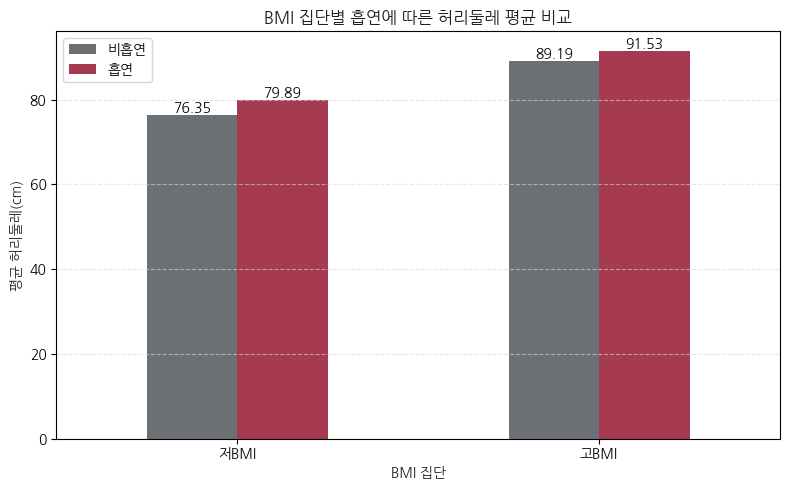

In [ ]:
#가설3-2_고BMI와 흡연이 결합하면 허리둘레(내장지방)에 더 악영향을 줄 것이다

#허리둘레 상호작용 회귀분석
model_waist = smf.ols('Q("waist(cm)") ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
print(model_waist.summary())

#허리둘레 막대그래프
waist_plot = train_clean.groupby(['high_BMI', 'smoking'])['waist(cm)'].mean().unstack()
waist_plot.index = ['저BMI', '고BMI']
waist_plot.columns = ['비흡연', '흡연']

ax = waist_plot.plot(
    kind='bar',
    figsize=(8,5),
    color=[COLOR_NONSMOKER, COLOR_SMOKER]
)

plt.title('BMI 집단별 흡연에 따른 허리둘레 평균 비교', color=COLOR_TEXT)
plt.xlabel('BMI 집단', color=COLOR_TEXT)
plt.ylabel('평균 허리둘레(cm)', color=COLOR_TEXT)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

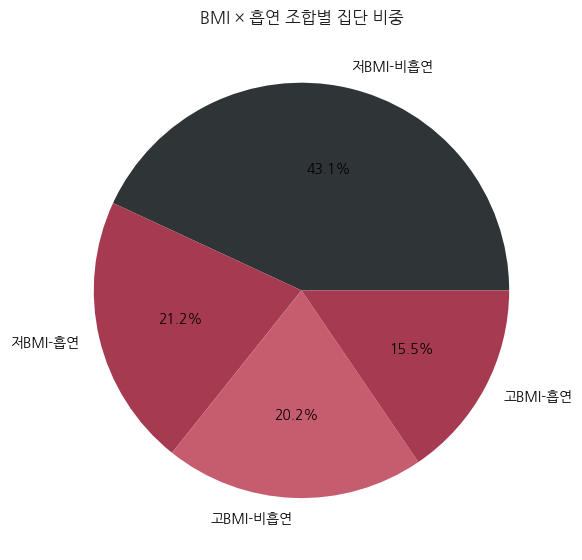

In [ ]:
#결론
#파이차트_개입 타겟 집단 비중
target_count = train_clean.groupby(['high_BMI','smoking']).size()
labels = ['저BMI-비흡연', '저BMI-흡연', '고BMI-비흡연', '고BMI-흡연']
colors = [COLOR_LOW_BMI, COLOR_SMOKER, COLOR_HIGH_BMI, COLOR_SMOKER]

plt.figure(figsize=(6,6))
plt.pie(target_count.values, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title('BMI × 흡연 조합별 집단 비중', color=COLOR_TEXT)
plt.tight_layout()
plt.show()

In [ ]:
#결론
#고BMI 흡연자 위험 강조 그래프
target_vars = ['ALT', 'Gtp', 'HDL', 'waist(cm)']
target_mean = train_clean.groupby(['high_BMI','smoking'])[target_vars].mean()

display(target_mean)

ALT        Gtp        HDL  waist(cm)
high_BMI smoking                                            
0        0        20.811837  25.956868  61.815911  76.347116
         1        25.417336  47.262966  56.860117  79.892622
1        0        31.961705  39.480980  53.955451  89.194524
         1        37.922320  61.484081  49.655276  91.527738

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COLOR_SMOKER = '#A63A50'       # 흡연자 강조
COLOR_HIGH_BMI = '#C65D6E'     # 고BMI 강조
COLOR_NONSMOKER = '#6B7075'    # 비흡연자
COLOR_LOW_BMI = '#2F3437'      # 저BMI
COLOR_TEXT = '#1E1E1E'
COLOR_GRID = '#D9D9D9'

plt.rcParams['axes.unicode_minus'] = False

train_clean = train[
    (train['Gtp'] < 500) &
    (train['ALT'] < 500) &
    (train['AST'] < 500) &
    (train['LDL'] < 400) &
    (train['serum creatinine'] < 3.0) &
    (train['eyesight(left)'] <= 3.0) &
    (train['eyesight(right)'] <= 3.0)
].copy()


train_clean['BMI'] = train_clean['weight(kg)'] / ((train_clean['height(cm)'] / 100) ** 2)
train_clean['high_BMI'] = (train_clean['BMI'] >= 25).astype(int)

def make_group(row):
    if row['high_BMI'] == 0 and row['smoking'] == 0:
        return '저BMI-비흡연'
    elif row['high_BMI'] == 0 and row['smoking'] == 1:
        return '저BMI-흡연'
    elif row['high_BMI'] == 1 and row['smoking'] == 0:
        return '고BMI-비흡연'
    else:
        return '고BMI-흡연'

train_clean['group4'] = train_clean.apply(make_group, axis=1)

group_order = ['저BMI-비흡연', '저BMI-흡연', '고BMI-비흡연', '고BMI-흡연']
group_colors = [COLOR_LOW_BMI, COLOR_NONSMOKER, COLOR_HIGH_BMI, COLOR_SMOKER]

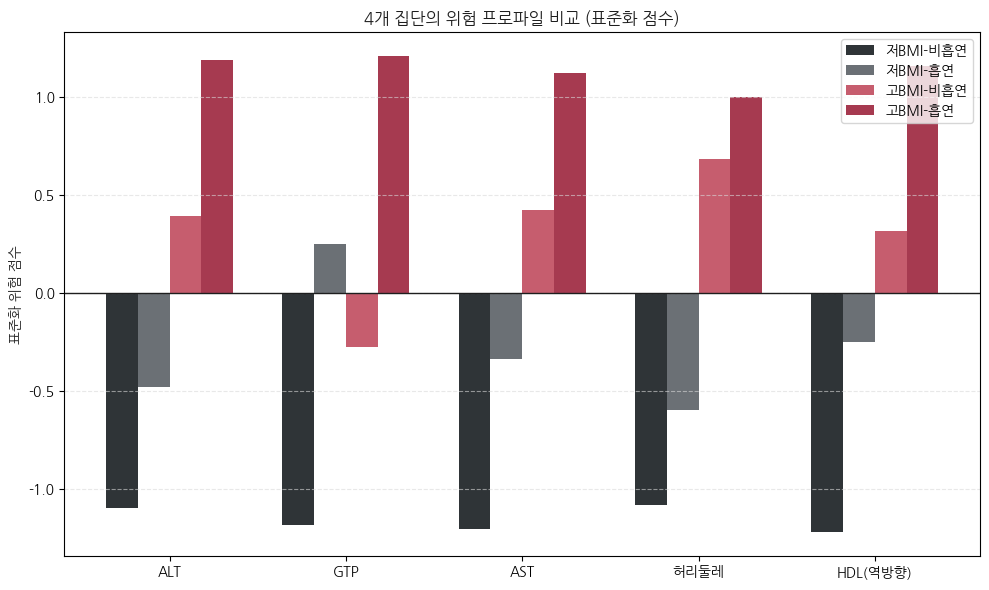

In [ ]:
# 위험 관련 변수 선택
risk_vars = ['ALT', 'Gtp', 'AST', 'waist(cm)', 'HDL']

# 4개 집단 평균
group_mean = train_clean.groupby('group4')[risk_vars].mean().loc[group_order]

# HDL은 높을수록 좋으므로, 위험 방향으로 뒤집기
group_mean_for_risk = group_mean.copy()
group_mean_for_risk['HDL'] = -group_mean_for_risk['HDL']

# 표준화(z-score)
risk_z = (group_mean_for_risk - group_mean_for_risk.mean()) / group_mean_for_risk.std()

# 그래프
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(risk_vars))
width = 0.18

for i, grp in enumerate(group_order):
    ax.bar(
        x + (i - 1.5) * width,
        risk_z.loc[grp].values,
        width=width,
        label=grp,
        color=group_colors[i]
    )

ax.axhline(0, color=COLOR_TEXT, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(['ALT', 'GTP', 'AST', '허리둘레', 'HDL(역방향)'])
ax.set_title('4개 집단의 위험 프로파일 비교 (표준화 점수)', color=COLOR_TEXT)
ax.set_ylabel('표준화 위험 점수', color=COLOR_TEXT)
ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()

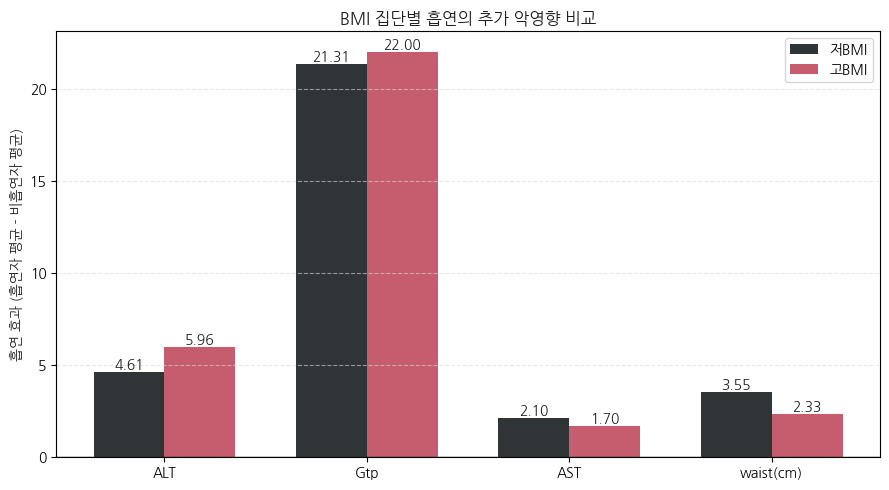

,변수,저BMI에서 흡연 효과,고BMI에서 흡연 효과
0,ALT,4.605499,5.960615
1,Gtp,21.306098,22.003100
2,AST,2.104104,1.701220
3,waist(cm),3.545507,2.333214


In [ ]:
# 저BMI/고BMI별 흡연 효과 계산
interaction_vars = ['ALT', 'Gtp', 'AST', 'waist(cm)']

rows = []
for var in interaction_vars:
    low_non = train_clean[(train_clean['high_BMI'] == 0) & (train_clean['smoking'] == 0)][var].mean()
    low_smk = train_clean[(train_clean['high_BMI'] == 0) & (train_clean['smoking'] == 1)][var].mean()
    high_non = train_clean[(train_clean['high_BMI'] == 1) & (train_clean['smoking'] == 0)][var].mean()
    high_smk = train_clean[(train_clean['high_BMI'] == 1) & (train_clean['smoking'] == 1)][var].mean()

    rows.append([
        var,
        low_smk - low_non,
        high_smk - high_non
    ])

effect_df = pd.DataFrame(rows, columns=['변수', '저BMI에서 흡연 효과', '고BMI에서 흡연 효과'])

# 그래프
x = np.arange(len(effect_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, effect_df['저BMI에서 흡연 효과'], width,
               color=COLOR_LOW_BMI, label='저BMI')
bars2 = ax.bar(x + width/2, effect_df['고BMI에서 흡연 효과'], width,
               color=COLOR_HIGH_BMI, label='고BMI')

ax.set_xticks(x)
ax.set_xticklabels(effect_df['변수'])
ax.axhline(0, color=COLOR_TEXT, linewidth=1)
ax.set_title('BMI 집단별 흡연의 추가 악영향 비교', color=COLOR_TEXT)
ax.set_ylabel('흡연 효과 (흡연자 평균 - 비흡연자 평균)', color=COLOR_TEXT)
ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
ax.legend()

for bars in [bars1, bars2]:
    for b in bars:
        y = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, y, f'{y:.2f}', ha='center', va='bottom', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

effect_df

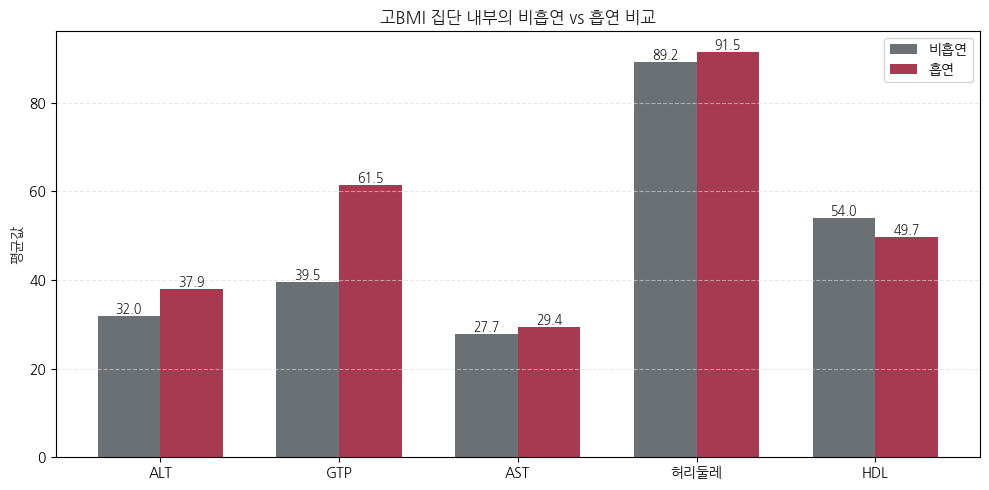

In [ ]:
# 고BMI 집단만 추출
high_bmi_df = train_clean[train_clean['high_BMI'] == 1].copy()

# 주요 변수 평균
target_vars = ['ALT', 'Gtp', 'AST', 'waist(cm)', 'HDL']
high_bmi_mean = high_bmi_df.groupby('smoking')[target_vars].mean().T
high_bmi_mean.columns = ['비흡연', '흡연']

# 그래프
x = np.arange(len(target_vars))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, high_bmi_mean['비흡연'], width, color=COLOR_NONSMOKER, label='비흡연')
bars2 = ax.bar(x + width/2, high_bmi_mean['흡연'], width, color=COLOR_SMOKER, label='흡연')

ax.set_xticks(x)
ax.set_xticklabels(['ALT', 'GTP', 'AST', '허리둘레', 'HDL'])
ax.set_title('고BMI 집단 내부의 비흡연 vs 흡연 비교', color=COLOR_TEXT)
ax.set_ylabel('평균값', color=COLOR_TEXT)
ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
ax.legend()

for bars in [bars1, bars2]:
    for b in bars:
        y = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, y, f'{y:.1f}', ha='center', va='bottom', color=COLOR_TEXT, fontsize=9)

plt.tight_layout()
plt.show()

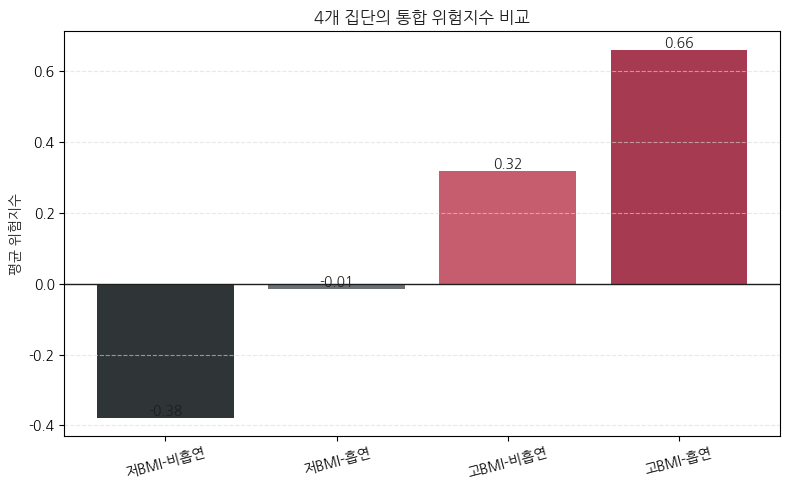

In [ ]:
risk_df = train_clean.copy()

# 위험 방향 통일
risk_df['HDL_risk'] = -risk_df['HDL']

risk_vars_score = ['ALT', 'Gtp', 'waist(cm)', 'HDL_risk']

# z-score 표준화
for col in risk_vars_score:
    risk_df[col + '_z'] = (risk_df[col] - risk_df[col].mean()) / risk_df[col].std()

risk_df['risk_score'] = risk_df[[c + '_z' for c in risk_vars_score]].mean(axis=1)

risk_score_mean = risk_df.groupby('group4')['risk_score'].mean().loc[group_order]

plt.figure(figsize=(8, 5))
bars = plt.bar(risk_score_mean.index, risk_score_mean.values, color=group_colors)

plt.axhline(0, color=COLOR_TEXT, linewidth=1)
plt.title('4개 집단의 통합 위험지수 비교', color=COLOR_TEXT)
plt.ylabel('평균 위험지수', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.xticks(rotation=15)

for i, v in enumerate(risk_score_mean.values):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom', color=COLOR_TEXT)

plt.tight_layout()
plt.show()